# Boston House Price Prediction using Machine Learning

This project predicts housing prices using machine learning models. The workflow includes:
- Data loading
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Model training
- Model comparison
- Feature importance analysis
- Feature selection
- Hyperparameter tuning


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [19]:
df = pd.read_csv(r"C:\Users\ganes\Desktop\ShadowFox\HousingData.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## Dataset Understanding

In [20]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

## Data Preprocessing

In [21]:
df.fillna(df.median(), inplace=True)

## Exploratory Data Analysis (EDA)

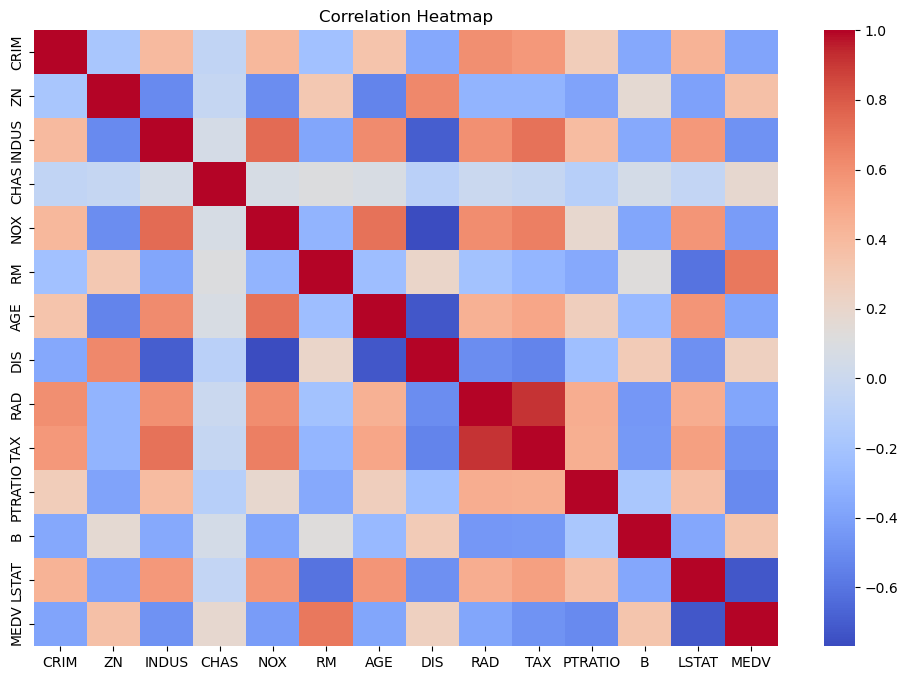

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Feature and Target Split

In [23]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

## Train Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Linear Regression Baseline Model

In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print('MSE:', mean_squared_error(y_test, y_pred_lr))
print('R2:', r2_score(y_test, y_pred_lr))

MSE: 24.99938479010357
R2: 0.6591013893903483


## Random Forest Model
Random Forest was selected because it captures non-linear relationships between variables and reduces overfitting through ensemble learning.

In [26]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('MSE:', mean_squared_error(y_test, y_pred_rf))
print('R2:', r2_score(y_test, y_pred_rf))

MSE: 8.219692490196078
R2: 0.8879139717607898


## Feature Importance

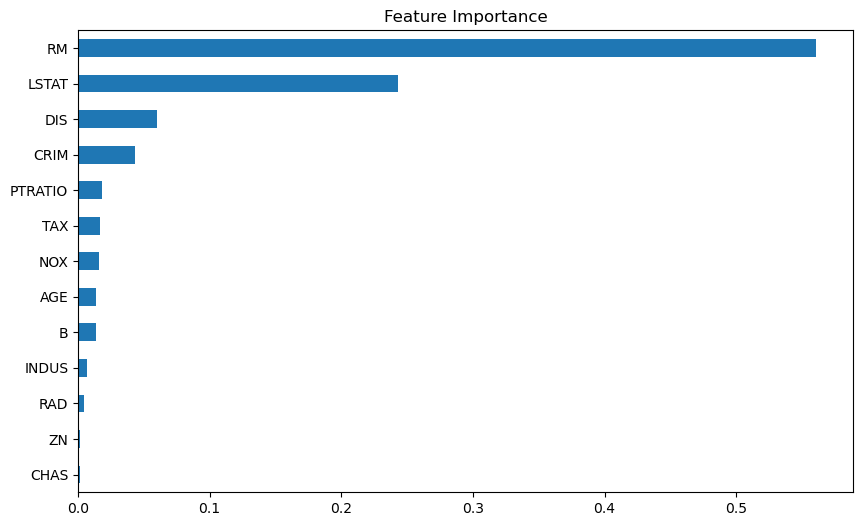

In [27]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
plt.title('Feature Importance')
plt.show()

## Feature Selection

In [28]:
top_features = feature_importance.sort_values(ascending=False).index[:8]

X_reduced = df[top_features]
y = df['MEDV']

## Train Model with Reduced Features

In [29]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

rf_reduced = RandomForestRegressor(random_state=42)
rf_reduced.fit(X_train_r, y_train_r)

y_pred_r = rf_reduced.predict(X_test_r)

print('MSE:', mean_squared_error(y_test_r, y_pred_r))
print('R2:', r2_score(y_test_r, y_pred_r))

MSE: 8.644013186274512
R2: 0.8821278159429345


## Hyperparameter Tuning

In [30]:
param_grid = {
    'n_estimators': [100,200,300,500],
    'max_depth': [None,5,10,20],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_r, y_train_r)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## Final Model Evaluation

In [31]:
best_rf = rf_random.best_estimator_

y_pred_tuned = best_rf.predict(X_test_r)

print('MSE:', mean_squared_error(y_test_r, y_pred_tuned))
print('R2:', r2_score(y_test_r, y_pred_tuned))

MSE: 9.518033628512267
R2: 0.8702094284744064


## Conclusion

Random Forest significantly outperformed Linear Regression.
Feature importance analysis revealed that RM and LSTAT are the most influential features.
Feature selection helped simplify the model while maintaining strong performance.
The final model demonstrates a complete machine learning pipeline.

In [37]:
def predict_house_price(model, input_data):
    input_df = pd.DataFrame([input_data], columns=top_features)
    prediction = model.predict(input_df)
    return prediction[0]
example_house = X_test_r.iloc[0]

predicted_price = predict_house_price(rf_reduced, example_house)

print("Predicted Price:", predicted_price)

Predicted Price: 23.666999999999998
